In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
df = pd.read_csv("../datasets/X_review_GP/processed/final_clean_dataset.csv")
df.head()

,text,rating,label,clean_text,text_length
0,"ya,bagus",4,positive,ya bagus,8
1,mohon bantuannya saya tidak bisa mengubah nama...,2,negative,mohon bantu ubah nama guna,26
2,tolong lah X (sebelumnya Twiter) akun saya tid...,3,neutral,tolong x twiter akun upload langgar tdk koment...,80
3,update selalu 🫰🏻,5,positive,update,6
4,"sangat menyebalkan, hampir setiap membuka apk ...",1,negative,sebal buka apk x pinta verifikasi email,39


In [3]:
print(f"Baris dan kolom: {df.shape}")

# Label Distribution
print("\nLabel Distribution:")
print("=" * 30)
print(df["label"].value_counts())

# Missing Values
print("\n\nMissing Values:")
print("=" * 30)
print(df.isnull().sum())

Baris dan kolom: (64341, 5)

Label Distribution:
label
negative    41994
positive    18544
neutral      3803
Name: count, dtype: int64


Missing Values:
text           0
rating         0
label          0
clean_text     0
text_length    0
dtype: int64


## 1. Feature & Target Split 

In [4]:
X = df["clean_text"]
y = df["label"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 2. TF-IDF Vectorization

In [5]:
# Vectorizer
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

# Fit & Transform
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## 3. Train Logistic Regression

In [6]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

## 4. Prediction

In [7]:
y_pred = model.predict(X_test_tfidf)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification Report
print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.7134975522573627
              precision    recall  f1-score   support

    negative       0.90      0.72      0.80      8399
     neutral       0.12      0.36      0.18       761
    positive       0.72      0.77      0.74      3709

    accuracy                           0.71     12869
   macro avg       0.58      0.61      0.58     12869
weighted avg       0.80      0.71      0.75     12869



- Model Logistic Regression menunjukkan performa yang cukup baikdalam mengklasifikasikan sentiment negative dan positive.
- Class negative memiliki precision yang sangat tinggi, yang menunjukkan bahwa prediksi negative model cukup akurat.
- Class positive juga menunjukkan performa yang cukup stabil dengan precision dan recall yang seimbang.
- Tapi, model masih mengalami kesulitan dalam mengenali class neutral. Hal ini terlihat dari rendahnya precision, recall, dan f1-score pada class neutral.
\
\
Kemungkinan penyebabnya adalah:
- distribusi dataset yang imbalance,
- jumlah sample neutral yang jauh lebih sedikit,
- karakteristik text neutral yang ambigu.
\
\
Secara keseluruhan,
baseline model sudah mampu mempelajari pola sentiment dengan cukup baik
dan dapat dijadikan fondasi
untuk tahap optimization berikutnya.

## 5. Confusion Matrix

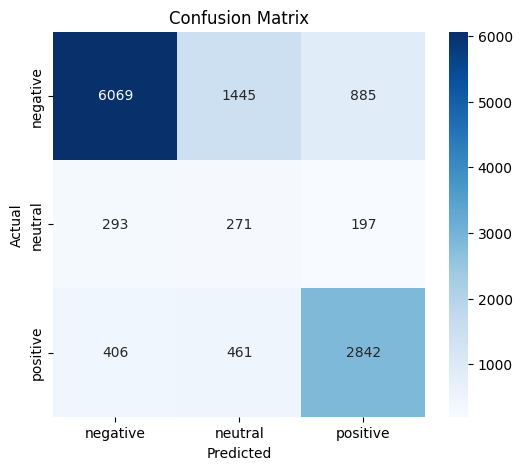

In [8]:
cm = confusion_matrix(y_test, y_pred)

# Visualisasi
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Kesimpulan Confusion Matrix

**Berdasarkan Confusion Matrix:**
- Model Logistic Regression menunjukkan performa yang cukup baik dalam mengklasifikasikan sentiment text. Sebagian besar prediksi berada pada diagonal utama.
- Class negative memiliki performa terbaik, terlihat dari jumlah prediksi benar yang paling tinggi **(6069)**. Hal ini mungkin dipengaruhi oleh jumlah data negative yang lebih dominan pada dataset.
- Class positive juga menunjukan performa yang cukup baik meskipun masih ada beberapa sample positive yang diprediksi sebagai neutral ataupun negative.
- Class neutral menjadi class yang paling sulit untuk diprediksi. Hal ini terlihat dari jumlah prediksi benar yang relatif kecil dibandingkan kesalahan prediksinya **(271)**.
- Kesulitan dalam mengenali neutral sentiment adalah hal yang umum dalam sentiment analysis karena text neutral sering memiliki karakteristik yang ambigu dan tidak mengandung kata sentiment yang kuat. Selain itu, distribusi dataset yang imbalance juga memengaruhi performa model, terutama pada class neutral yang memiliki jumlah data paling sedikit **(3083)**
\
\
Pada tahap berikutnya,
model dapat ditingkatkan menggunakan:
- slang normalization
- hyperparameter tuning
- model comparison
- advanced NLP model seperti IndoBERT.

## 6. Test Prediction Manual

In [9]:
# Positif
sample = ["aplikasi ini oke"]
sample_tfidf = tfidf.transform(sample)
prediction = model.predict(sample_tfidf)
print(prediction)

['positive']


In [10]:
# Negatif
sample = ["aplikasi ini jelek dan lemot sekali"]
sample_tfidf = tfidf.transform(sample)
prediction = model.predict(sample_tfidf)
print(prediction)

['negative']


In [11]:
sample = ["aplikasi ini digunakan untuk komunikasi"]
sample_tfidf = tfidf.transform(sample)
prediction = model.predict(sample_tfidf)
print(prediction)

['positive']


## 7. Save model

In [12]:
joblib.dump(
    model,
    "../models/logistic_regression_model.pkl"
)

joblib.dump(
    tfidf,
    "../models/tfidf_vectorizer.pkl"
)

['../models/tfidf_vectorizer.pkl']